In [1]:
import warnings
warnings.filterwarnings("ignore")
import os, pandas as pd, matplotlib.pyplot as plt, numpy as np, seaborn as sns, glob


In [2]:
df = pd.read_csv('FRs_and_gaze_P54CS_R1.csv')
df.head()

,frame,gun_with_protagonist,gun_closeup,protagonist,misc_char,mom,uncle,dad,unrevealed_object_protag_looks_at,bullets,...,vmPFC_neur83,vmPFC_neur84,vmPFC_neur85,vmPFC_neur86,vmPFC_neur87,vmPFC_neur88,vmPFC_neur89,vmPFC_neur90,vmPFC_neur91,vmPFC_neur92
0,11,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.898057,3.761152,-1.321287,0.537737,1.087061,0.533536,-0.079829,1.800714,-0.838468,-1.352067
1,12,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.296837,0.870299,1.743970,-0.792602,-0.941835,2.820804,0.225967,-0.877801,-0.838468,0.495196
2,13,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,-0.296837,0.870299,-0.554973,0.537737,-0.941835,1.448443,-0.691419,0.907875,1.235867,0.495196
3,14,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,-0.296837,-1.056936,0.211341,-0.792602,0.072613,0.990989,2.060738,0.015037,-0.838468,0.495196
4,15,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.300610,0.870299,-1.321287,-0.792602,-0.941835,1.448443,-0.997215,0.015037,0.198699,-0.120558


## plotting objects gazed at

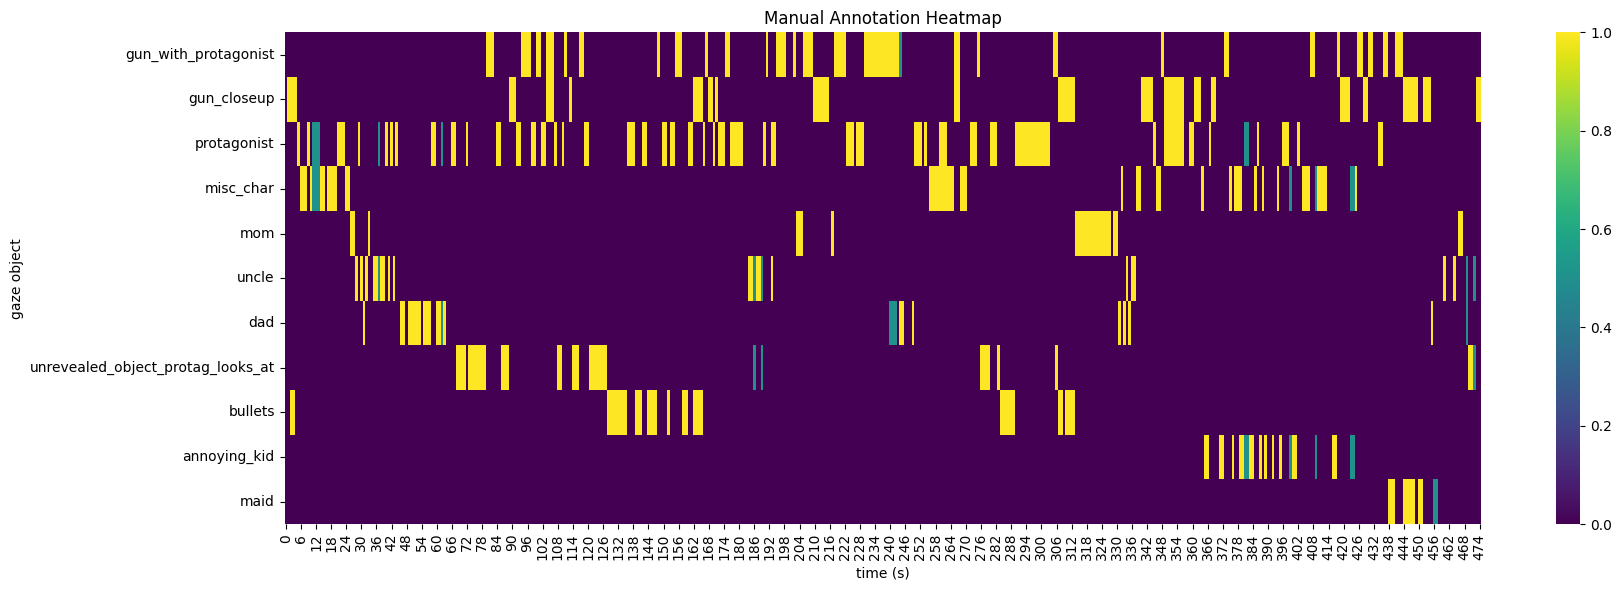

In [3]:
gaze_cols = [col for col in df.columns if 'neur' not in col and 'frame' not in col]
df_gaze = df[gaze_cols]

plt.figure(figsize=(18, 6))
sns.heatmap(df_gaze.T, cmap='viridis', cbar=True)
plt.xlabel('time (s)')
plt.ylabel('gaze object')
plt.title('Manual Annotation Heatmap')
plt.tight_layout()
plt.show()


## plotting boxcar normed FRs
### note that a few outliers make it difficult to see neuronal variation. see more in the next block.

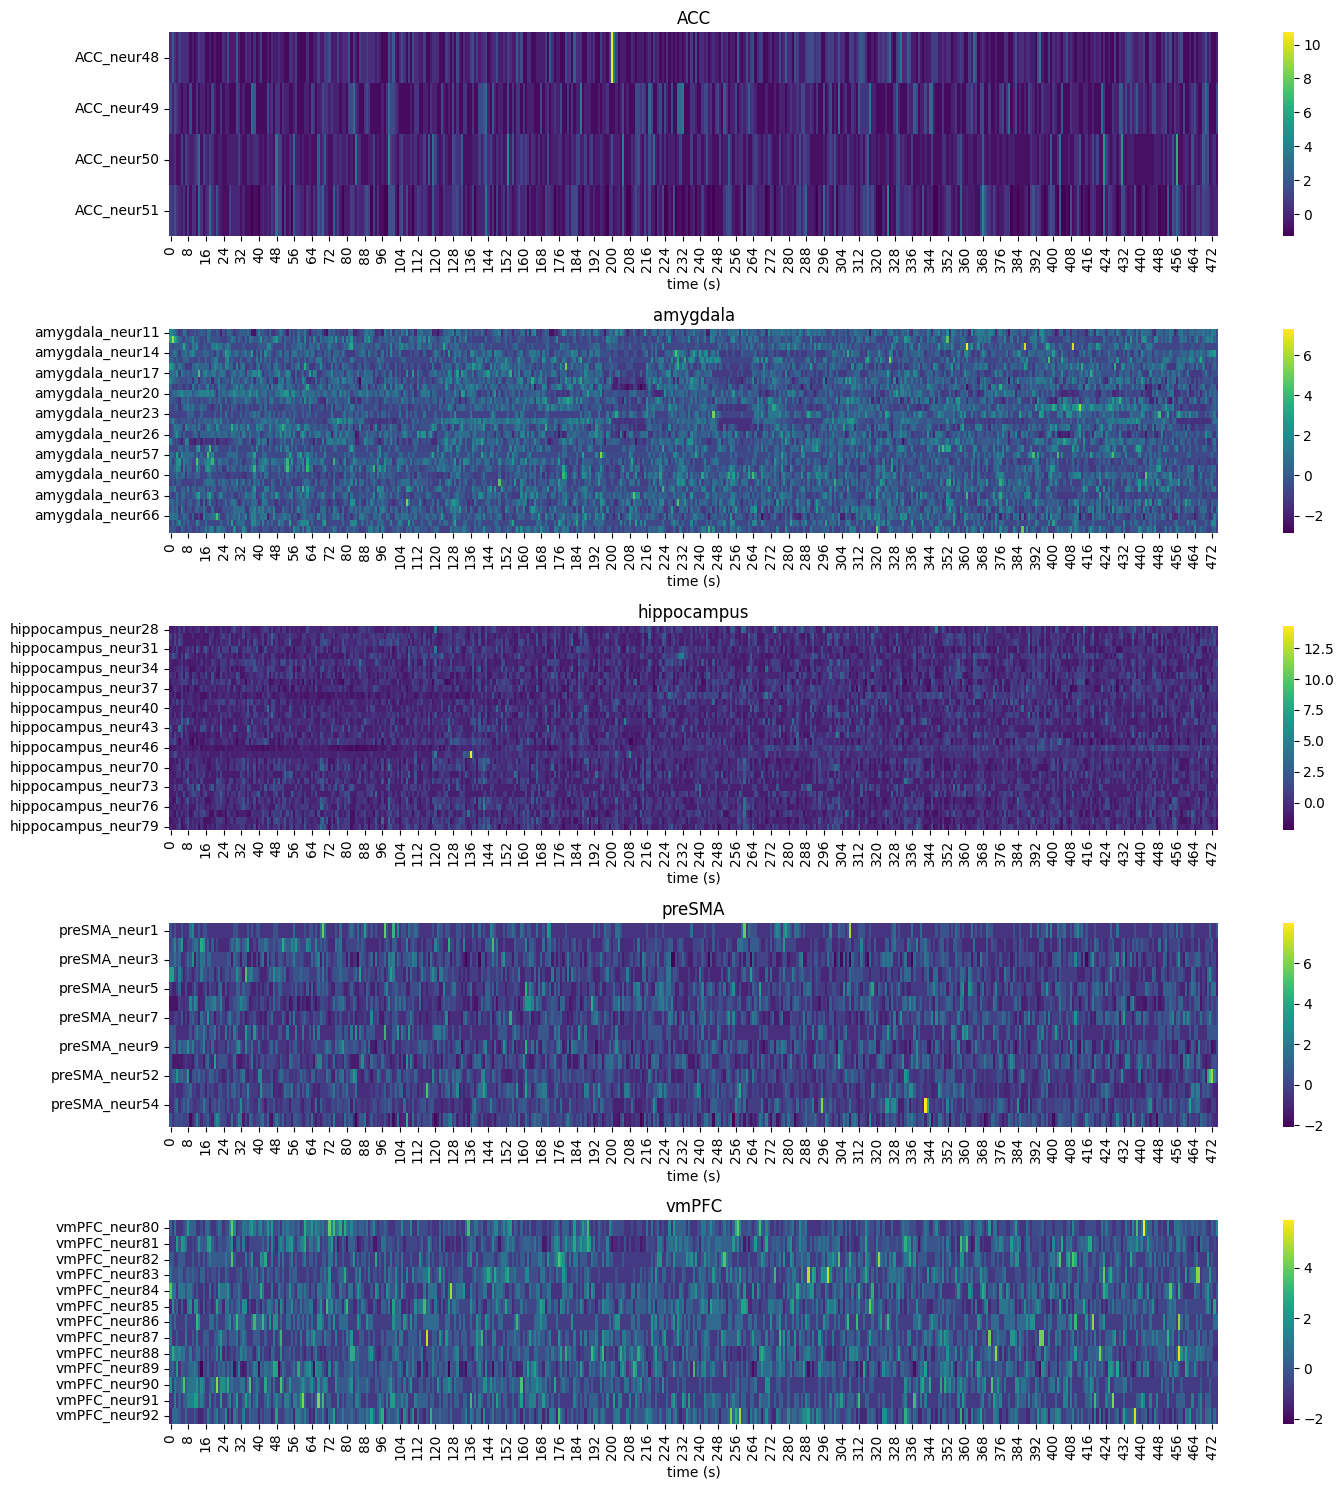

In [4]:
# get all region names from neuron col names
neuron_cols = [col for col in df.columns if '_neur' in col]
regions = sorted(set([col.split('_neur')[0] for col in neuron_cols]))

fig, axs = plt.subplots(5, 1, figsize=(15, 15))
axs, ax = axs.flatten(), 0

for region in regions:

    # grab columns for the current region
    region_cols = [col for col in df.columns if col.startswith(region)]
    df_time_by_neur = df[region_cols]

    sns.heatmap(df_time_by_neur.T, cmap='viridis', cbar=True, ax=axs[ax])
    axs[ax].set(xlabel='time (s)', title = region)
    ax += 1

plt.tight_layout()
plt.show()

## thresholding plot to .99 percentile of FRs to ignore outliers

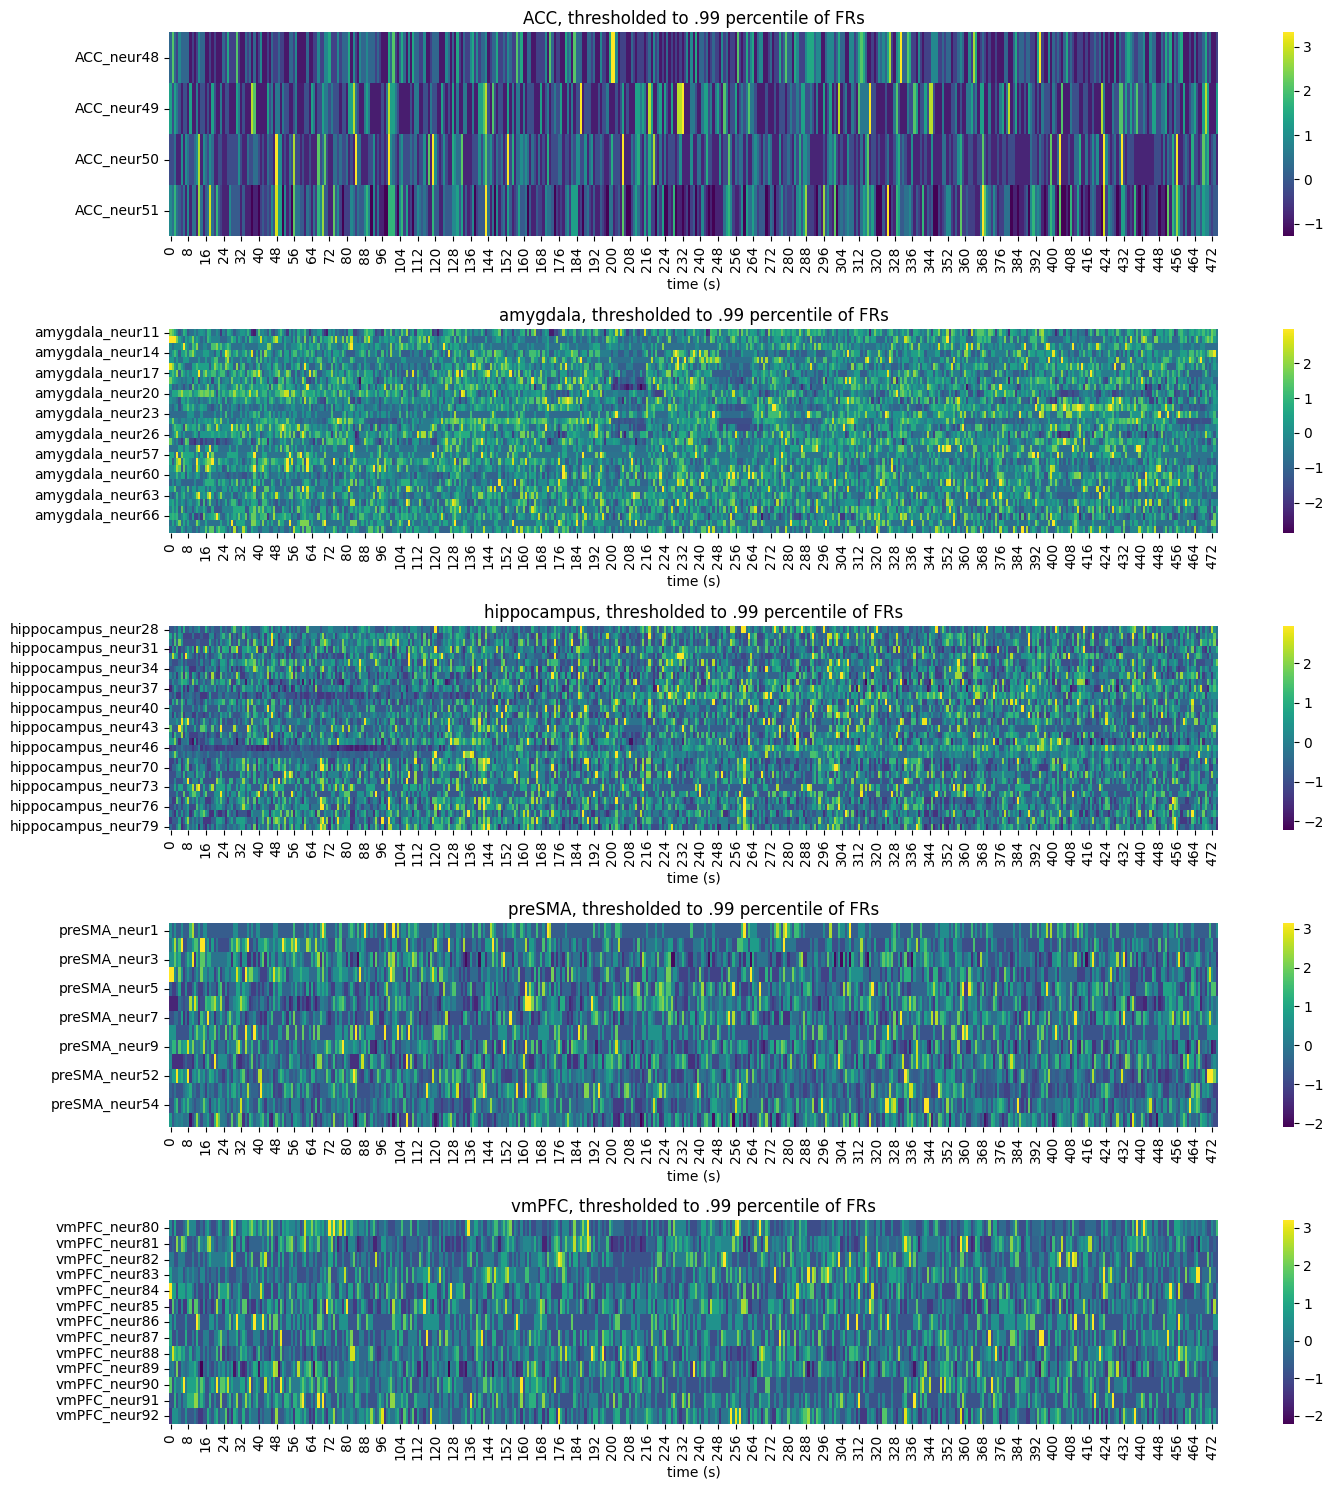

In [5]:
fig, axs = plt.subplots(5, 1, figsize=(15, 15))
axs, ax = axs.flatten(), 0

for region in regions:

    # grab columns for the current region
    region_cols = [col for col in df.columns if col.startswith(region)]
    df_time_by_neur = df[region_cols]

    sns.heatmap(df_time_by_neur.T, cmap='viridis', cbar=True, ax=axs[ax], vmax = np.percentile(df_time_by_neur.values, 99))
    axs[ax].set(xlabel='time (s)', title = f'{region}, thresholded to .99 percentile of FRs')
    ax += 1

plt.tight_layout()
plt.show()